# 1. reparación y carga de datos

# Configuración y obtención de datos

In [ ]:
!pip install sodapy

In [ ]:
import pandas as pd
import numpy as np
from sodapy import Socrata
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
client = Socrata("www.datos.gov.co", None)

results = client.get("e97j-vuf7", limit=358000)
# results = client.get(
#     "e97j-vuf7",
#     order="fecha_publicaci_n DESC",  # orden descendente por fecha
#     limit=1000                       # tomar los primeros 1000 de ese orden
# )
# Convert to pandas DataFrame
results_df = pd.DataFrame.from_records(results)

Inspección inicial de los datos

In [ ]:
results_df.info()
results_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358000 entries, 0 to 357999
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   fecha_publicaci_n           358000 non-null  object
 1   pais_prisi_n                358000 non-null  object
 2   consulado                   358000 non-null  object
 3   delito                      358000 non-null  object
 4   extraditado_y_o_repatriado  358000 non-null  object
 5   situaci_n_jur_dica          358000 non-null  object
 6   g_nero                      358000 non-null  object
 7   grupo_edad                  358000 non-null  object
 8   geocoded_column             121827 non-null  object
 9   cantidad                    358000 non-null  object
 10  latitud                     313678 non-null  object
 11  longitud                    313678 non-null  object
dtypes: object(12)
memory usage: 32.8+ MB


(358000, 12)

In [ ]:
print(results_df.head())

  fecha_publicaci_n    pais_prisi_n      consulado        delito  \
0        2018-09-17         ECUADOR       C. QUITO  NARCOTRÁFICO   
1        2018-09-17          ITALIA        C. ROMA         OTROS   
2        2018-09-17  ESTADOS UNIDOS  C. NUEVA YORK     EXTORSIÓN   
3        2018-09-17          MEXICO      C. MEXICO         OTROS   
4        2018-09-17           JAPON       C. TOKIO  ROBO / HURTO   

  extraditado_y_o_repatriado situaci_n_jur_dica     g_nero    grupo_edad  \
0                DESCONOCIDO          EN JUICIO  MASCULINO   DESCONOCIDO   
1                DESCONOCIDO   EN INVESTIGACIÓN  MASCULINO   DESCONOCIDO   
2                DESCONOCIDO          CONDENADO  MASCULINO        ADULTO   
3                DESCONOCIDO   EN INVESTIGACIÓN  MASCULINO  ADULTO JOVEN   
4                DESCONOCIDO          CONDENADO   FEMENINO  ADULTO MAYOR   

                                     geocoded_column cantidad    latitud  \
0  {'latitude': '-1.831239', 'longitude': '-78.18...      

In [ ]:
results_df.describe(include="all")

,fecha_publicaci_n,pais_prisi_n,consulado,delito,extraditado_y_o_repatriado,situaci_n_jur_dica,g_nero,grupo_edad,geocoded_column,cantidad,latitud,longitud
count,358000,358000,358000,358000,358000,358000,358000,358000,121827,358000,313678,313678
unique,60,93,121,40,4,8,5,7,159,363,93,93
top,2022-01-24,DESCONOCIDO,C. MADRID,NARCOTR�FICO,DESCONOCIDO,CONDENADO,MASCULINO,ADULTO,"{'latitude': '0.0', 'longitude': '0.0', 'human...",1,6.42375,-66.58973
freq,32406,201699,22150,55081,337150,150958,281880,159317,25995,199186,48080,48080


In [ ]:
results_df.isnull().sum()

,0
fecha_publicaci_n,0
pais_prisi_n,0
consulado,0
delito,0
extraditado_y_o_repatriado,0
situaci_n_jur_dica,0
g_nero,0
grupo_edad,0
geocoded_column,236173
cantidad,0


In [ ]:
results_df.groupby('delito').size()

,0
delito,
ALLANAMIENTO,853
AMENAZAS,2413
CELEBRACIÓN INDEBIDA DE CONTRATOS,65
CELEBRACI�N INDEBIDA DE CONTRATOS,92
COACCIÓN,203
COACCI�N,315
CONDUCCIÓN TEMERARIA,764
CONDUCCI�N TEMERARIA,1441
CONTRABANDO,5099


In [ ]:
def count_specific_values(df, columns):
    for col in columns:
        if col in df.columns:
            desconocido_count = df[col].astype(str).str.lower().eq('desconocido').sum()
            print(f"Column '{col}':")
            print(f"  Count of 'desconocido': {desconocido_count}")

            try:
                zero_count = (df[col] == 0).sum()
                print(f"  Count of 0: {zero_count}")
            except TypeError:
                print(f"  Could not count 0 in column '{col}' due to mixed data types.")
            print("-" * 20)
        else:
            print(f"Column '{col}' not found in DataFrame.")
            print("-" * 20)

print("Count of 'desconocido' and 0 in each column:")
count_specific_values(results_df, ['pais_prisi_n', 'consulado', 'delito', 'extraditado_y_o_repatriado', 'situaci_n_jur_dica', 'g_nero', 'grupo_edad'])
#

Count of 'desconocido' and 0 in each column:
Column 'pais_prisi_n':
  Count of 'desconocido': 201699
  Count of 0: 0
--------------------
Column 'consulado':
  Count of 'desconocido': 0
  Count of 0: 0
--------------------
Column 'delito':
  Count of 'desconocido': 36071
  Count of 0: 0
--------------------
Column 'extraditado_y_o_repatriado':
  Count of 'desconocido': 337150
  Count of 0: 0
--------------------
Column 'situaci_n_jur_dica':
  Count of 'desconocido': 0
  Count of 0: 0
--------------------
Column 'g_nero':
  Count of 'desconocido': 252
  Count of 0: 0
--------------------
Column 'grupo_edad':
  Count of 'desconocido': 106602
  Count of 0: 0
--------------------


In [ ]:
results_df = results_df.replace('?',np.nan)

print('Number of instances = %d' % (results_df.shape[0]))
print('Number of attributes = %d' % (results_df.shape[1]))

print('Number of missing values:')
for col in results_df.columns:
    print('\t%s: %d' % (col,results_df[col].isna().sum()))

Number of instances = 358000
Number of attributes = 12
Number of missing values:
	fecha_publicaci_n: 0
	pais_prisi_n: 0
	consulado: 0
	delito: 0
	extraditado_y_o_repatriado: 0
	situaci_n_jur_dica: 0
	g_nero: 0
	grupo_edad: 0
	geocoded_column: 236173
	cantidad: 0
	latitud: 44322
	longitud: 44322


In [ ]:
# Configurar estilo de gráficos
sns.set(style="whitegrid")

# Cargar los datos (suponiendo que ya sea results_df)
df = results_df.copy()

# Corregir tipos de dato
df['fecha_publicaci_n'] = pd.to_datetime(df['fecha_publicaci_n'])
df['grupo_edad']      = df['grupo_edad'].astype('category')
df['pais_prisi_n']    = df['pais_prisi_n'].astype('category')
df['consulado']       = df['consulado'].astype('category')
df['delito']          = df['delito'].astype('category')
df['extraditado_y_o_repatriado'] = df['extraditado_y_o_repatriado'].astype('category')
df['situaci_n_jur_dica'] = df['situaci_n_jur_dica'].astype('category')
df['g_nero']          = df['g_nero'].astype('category')


In [ ]:
df1 = df.replace('?',np.nan)

print('Number of instances = %d' % (df1.shape[0]))
print('Number of attributes = %d' % (df1.shape[1]))

print('Number of missing values:')
for col in df1.columns:
    print('\t%s: %d' % (col,df1[col].isna().sum()))

Number of instances = 358000
Number of attributes = 12
Number of missing values:
	fecha_publicaci_n: 0
	pais_prisi_n: 0
	consulado: 0
	delito: 0
	extraditado_y_o_repatriado: 0
	situaci_n_jur_dica: 0
	g_nero: 0
	grupo_edad: 0
	geocoded_column: 236173
	cantidad: 0
	latitud: 44322
	longitud: 44322


# 2. Análisis de variables numéricas

In [ ]:
numeric_cols = ['cantidad', 'latitud', 'longitud']

print("Estadísticas descriptivas de variables numéricas:")
print(df[numeric_cols].describe())


Estadísticas descriptivas de variables numéricas:
       cantidad  latitud   longitud
count    358000   313678     313678
unique      363       93         93
top           1  6.42375  -66.58973
freq     199186    48080      48080


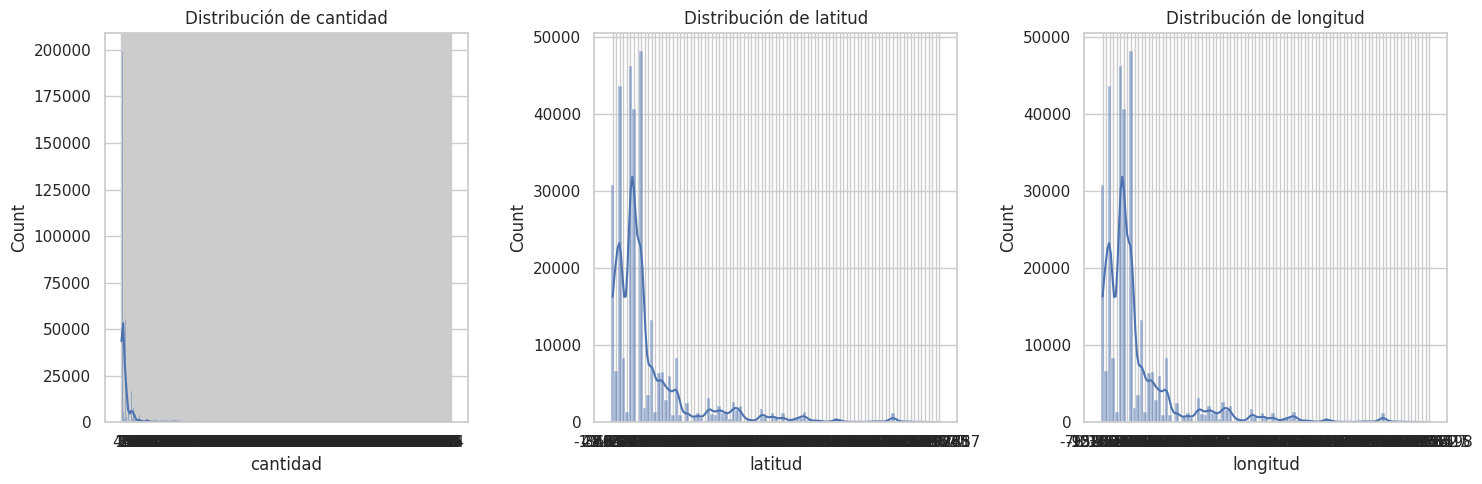

In [ ]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
plt.tight_layout()
plt.show()


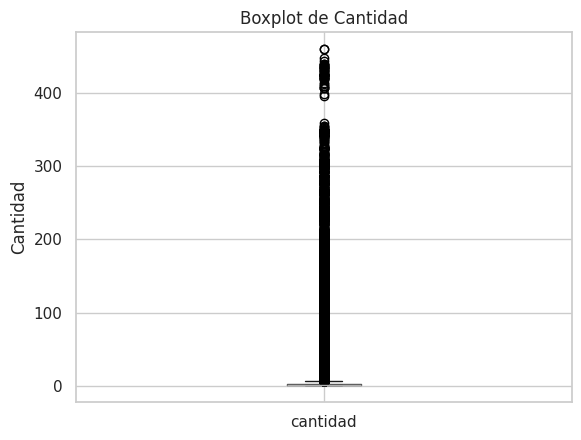

In [ ]:
df['cantidad'] = pd.to_numeric(df['cantidad'], errors='coerce')

#BOXPLOT CANTIDAD
df.boxplot(column='cantidad')
plt.title('Boxplot de Cantidad')
plt.ylabel('Cantidad')
plt.show()

In [ ]:
df.groupby('cantidad').size()

,0
cantidad,
1,199186
2,55206
3,24619
4,16615
5,10315
...,...
438,3
439,2
443,1


Interpretación:



*   cantidad suele concentrarse en valores bajos, con un cola larga hasta ~460 detenciones por reporte.

*   latitud y longitud muestran la dispersión geográfica de los países donde hay prisiones.

In [ ]:
# Estadísticas básicas
df['cantidad'].describe()

,cantidad
count,358000.000000
mean,4.818645
std,16.979822
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,460.000000


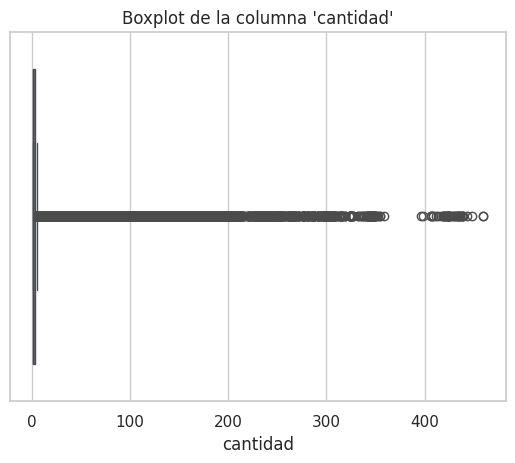

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['cantidad'])
plt.title("Boxplot de la columna 'cantidad'")
plt.show()


In [ ]:
Q1 = df['cantidad'].quantile(0.25)
Q3 = df['cantidad'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['cantidad'] < limite_inferior) | (df['cantidad'] > limite_superior)]

In [ ]:
outliers = df[(df['cantidad'] < limite_inferior) | (df['cantidad'] > limite_superior)]
print(f"Outliers encontrados: {len(outliers)}")
#print(outliers[['pais_prision', 'cantidad', 'fecha_publicacion']].sort_values(by='cantidad', ascending=False).head())

Outliers encontrados: 44153


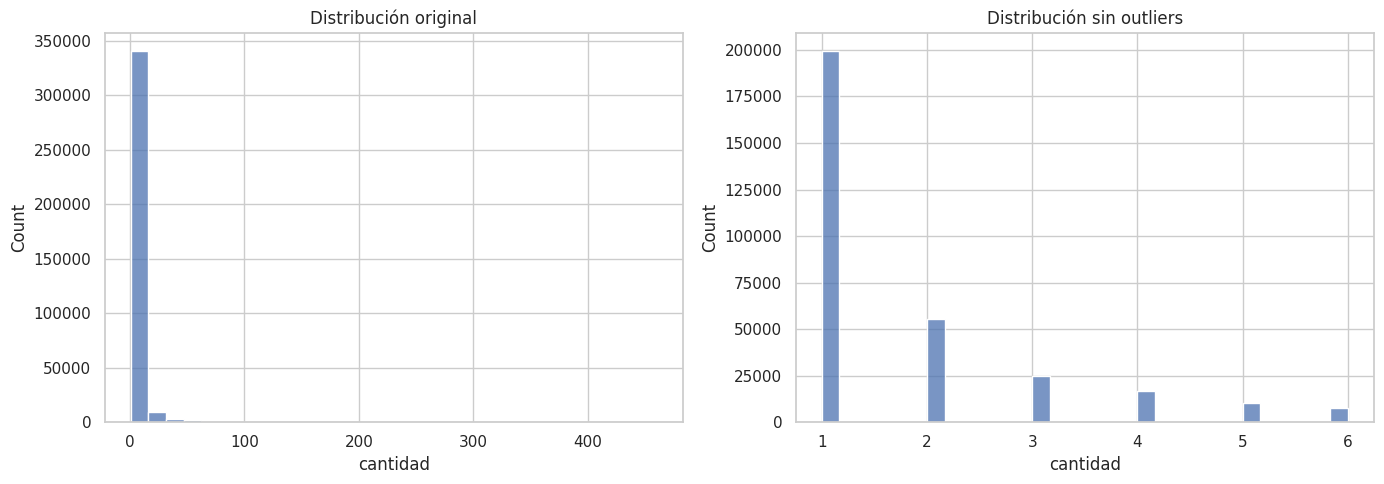

In [ ]:
# Histograma antes y después
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['cantidad'], bins=30, ax=axes[0])
axes[0].set_title('Distribución original')

# Filter out outliers to create df_filtrado
df_filtrado = df[(df['cantidad'] >= limite_inferior) & (df['cantidad'] <= limite_superior)]

sns.histplot(df_filtrado['cantidad'], bins=30, ax=axes[1])
axes[1].set_title('Distribución sin outliers')

plt.tight_layout()
plt.show()

In [ ]:
# Calcular porcentaje de outliers
total_registros = len(df)
total_outliers = len(outliers)
porcentaje_outliers = round((total_outliers / total_registros) * 100, 4)

print(f"Outliers encontrados: {total_outliers} de {total_registros} registros ({porcentaje_outliers}%)")

Outliers encontrados: 44153 de 358000 registros (12.3332%)


# Diagrama de dispersión geográfico con tamaño y color por cantidad

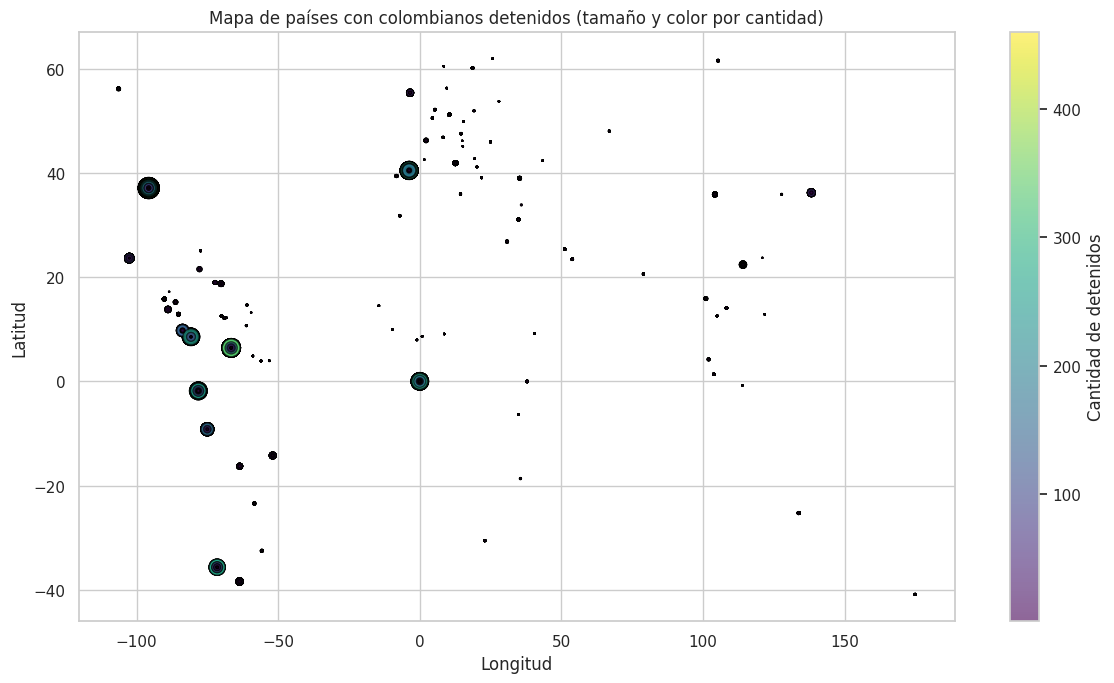

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Aseguramos que los datos sean numéricos
df['latitud'] = pd.to_numeric(df['latitud'], errors='coerce')
df['longitud'] = pd.to_numeric(df['longitud'], errors='coerce')
df['cantidad'] = pd.to_numeric(df['cantidad'], errors='coerce')

# Filtrar registros válidos (sin NaN)
df_geo = df.dropna(subset=['latitud', 'longitud', 'cantidad'])

# Crear scatter plot con tamaño y color por cantidad
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    df_geo['longitud'],
    df_geo['latitud'],
    s=df_geo['cantidad'] * 0.5,     # Tamaño relativo a la cantidad
    c=df_geo['cantidad'],           # Color basado en la cantidad
    cmap='viridis',
    alpha=0.6,
    edgecolor='black'
)

plt.colorbar(scatter, label='Cantidad de detenidos')
plt.title('Mapa de países con colombianos detenidos (tamaño y color por cantidad)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True)
plt.tight_layout()
plt.show()


# 3. Análisis de variables categóricas

In [ ]:
categorical_cols = [
    'pais_prisi_n', 'consulado', 'delito',
    'extraditado_y_o_repatriado',
    'situaci_n_jur_dica', 'g_nero', 'grupo_edad'
]

for col in categorical_cols:
    frec = df[col].value_counts(normalize=True).head(10)
    print(f"\nTop 10 categorías en '{col}':")
    print(frec)



Top 10 categorías en 'pais_prisi_n':
pais_prisi_n
DESCONOCIDO       0.563405
VENEZUELA         0.073925
ESTADOS UNIDOS    0.067958
ECUADOR           0.050221
ESPAÑA            0.038257
EXTRADICION       0.025383
ESPA�A            0.022151
CHILE             0.020799
MEXICO            0.013087
PANAMA            0.011598
Name: proportion, dtype: float64

Top 10 categorías en 'consulado':
consulado
C. MADRID          0.061872
C. PANAMA          0.033243
C. SANTIAGO        0.030693
BTA. ASISTENCIA    0.030494
C. QUITO           0.030478
C. MEXICO          0.029866
C. BUENOS AIRES    0.026640
C. BARCELONA       0.021237
C. MIAMI           0.021165
C. HOUSTON         0.020832
Name: proportion, dtype: float64

Top 10 categorías en 'delito':
delito
NARCOTR�FICO                0.153858
ROBO / HURTO                0.121416
DESCONOCIDO                 0.100757
NARCOTRÁFICO                0.082232
HOMICIDIO / TENTATIVA DE    0.077905
OTROS                       0.067349
DELITOS SEXUALES           

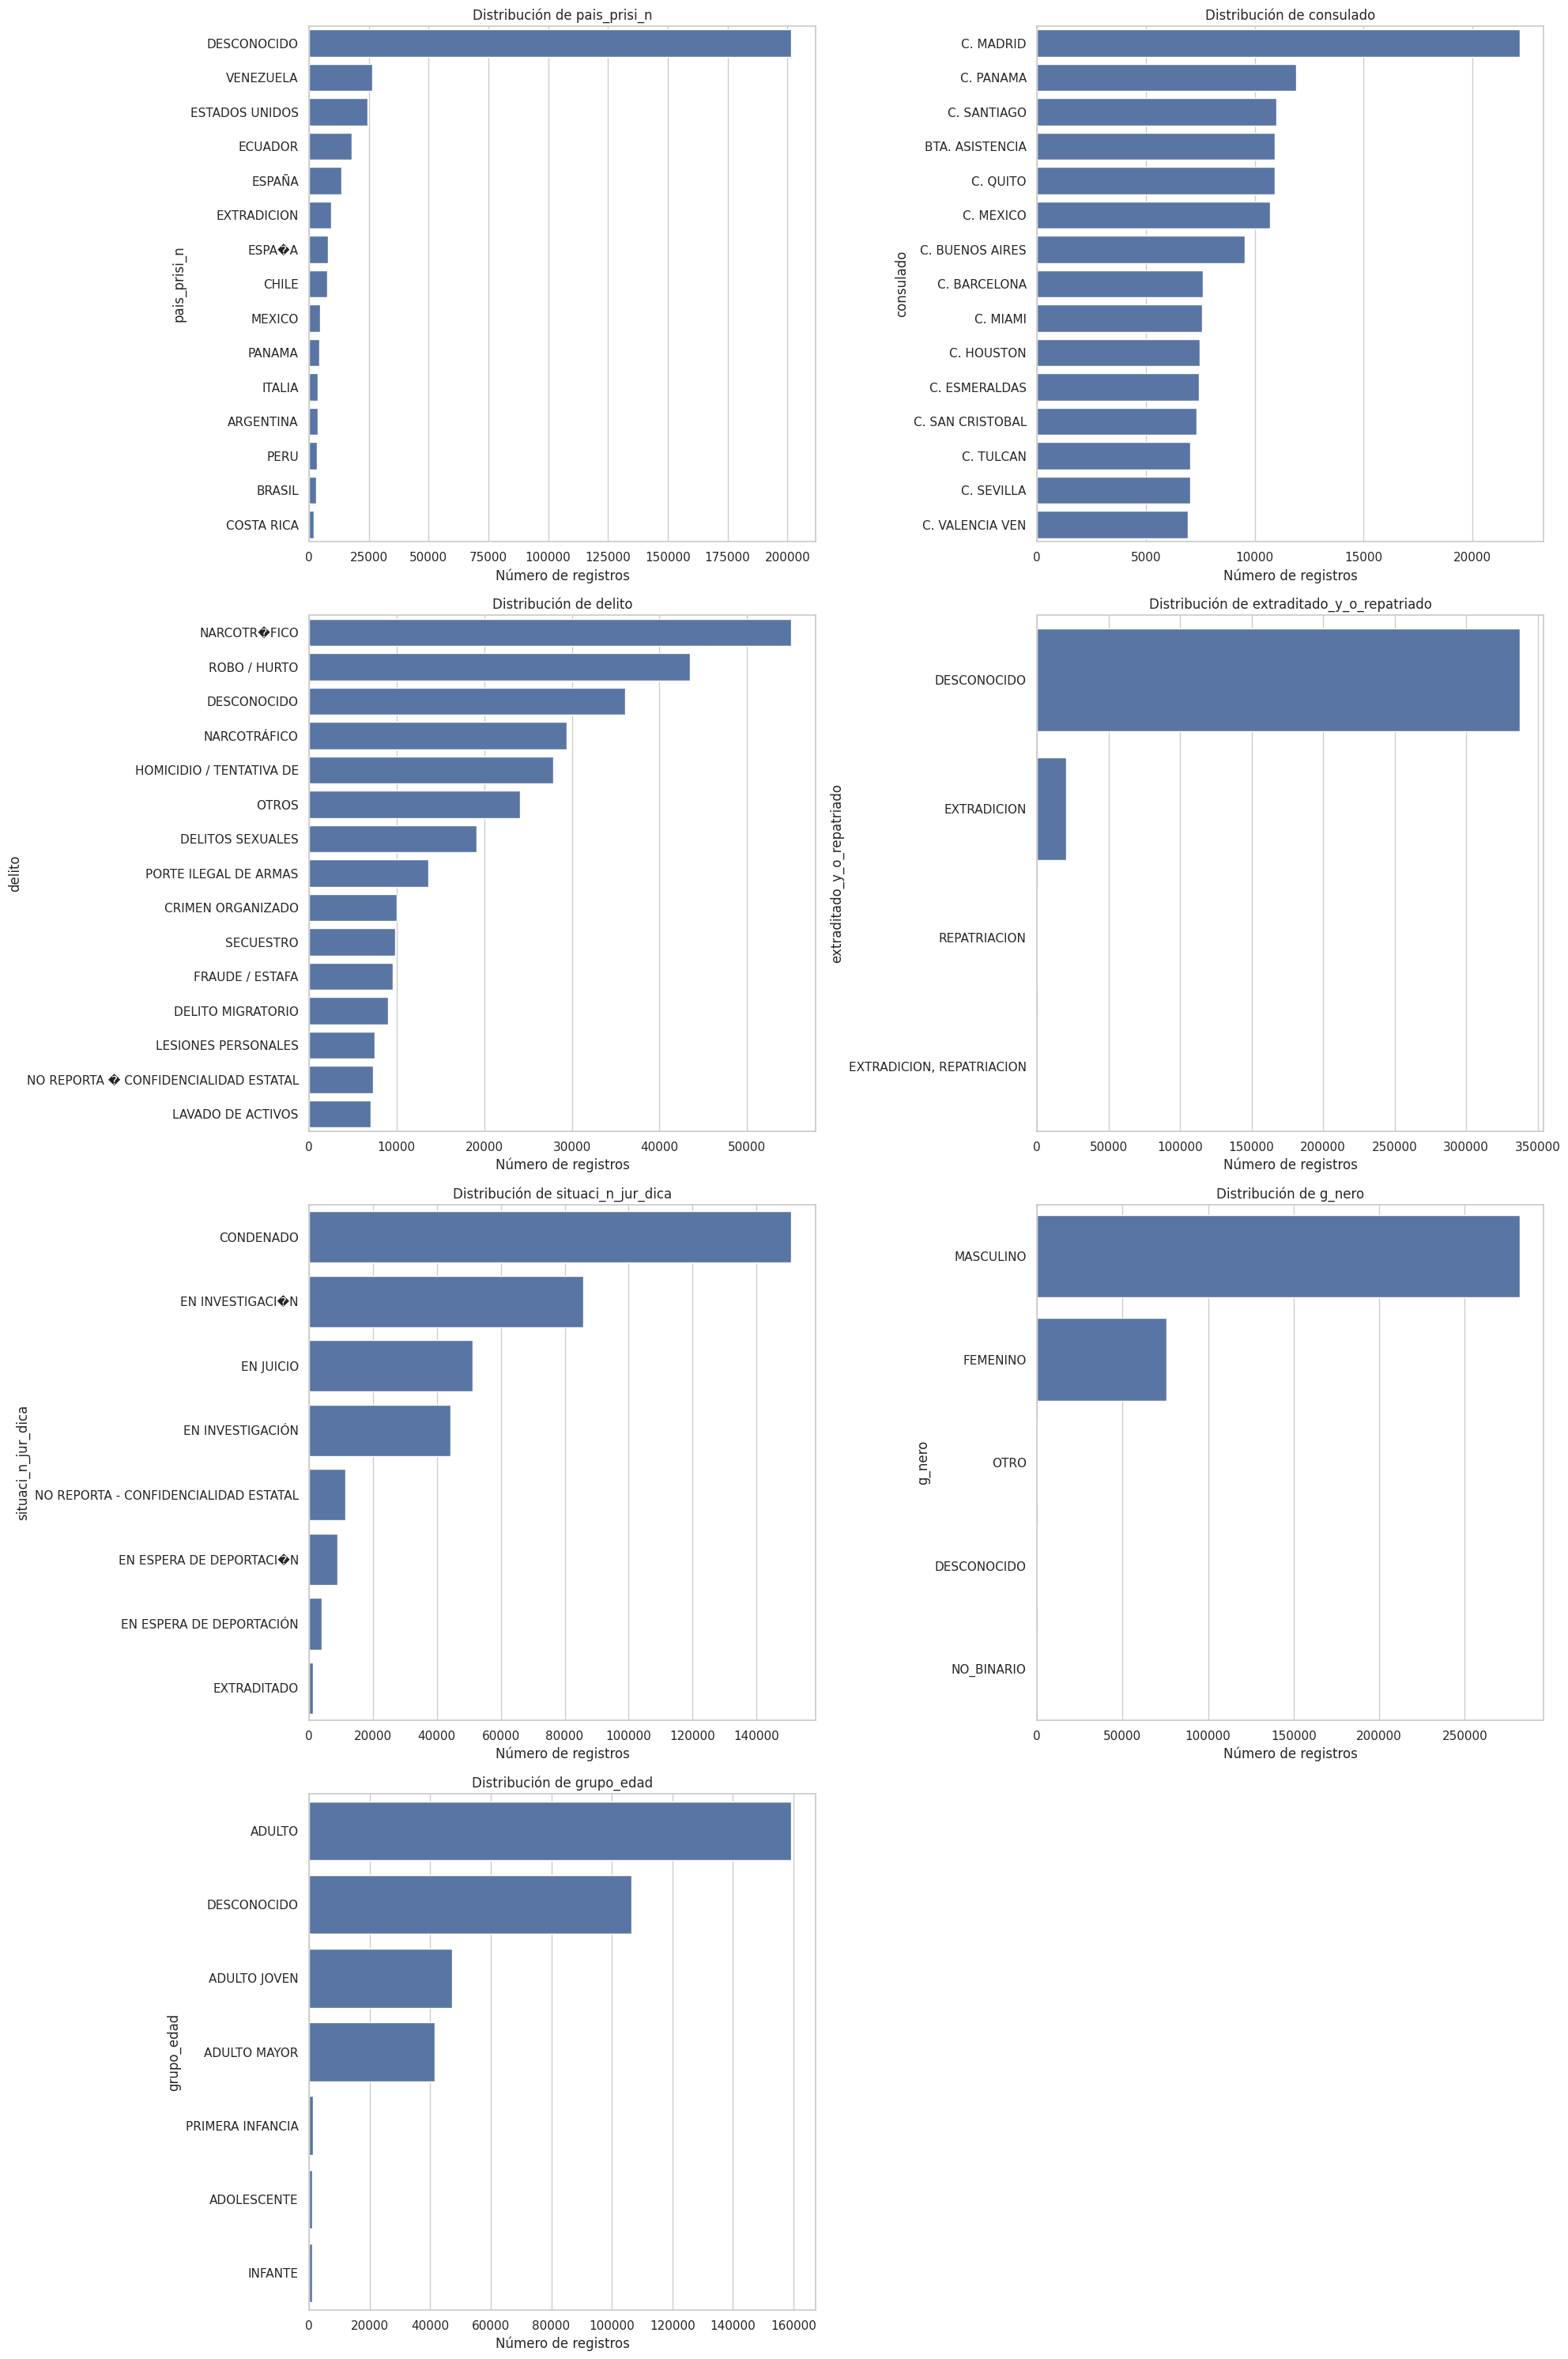

In [ ]:
plt.figure(figsize=(20, 30))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(4, 2, i)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:15])
    plt.title(f"Distribución de {col}")
    plt.xlabel("Número de registros")
    plt.ylabel(col)
plt.tight_layout()
plt.show()


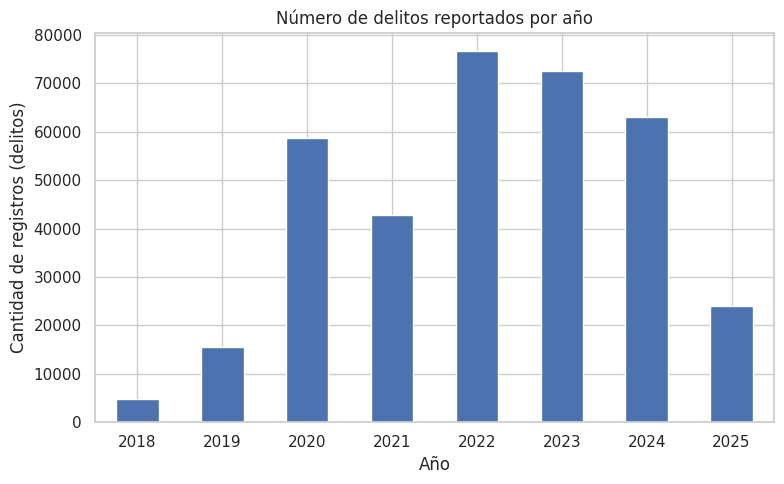

In [ ]:

df['año'] = df['fecha_publicaci_n'].dt.year

# Agrupar y contar registros (delitos) por año
delitos_por_año = df.groupby('año')['delito'].count()

# Graficar
delitos_por_año.plot(kind='bar', figsize=(8,5))
plt.title("Número de delitos reportados por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de registros (delitos)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


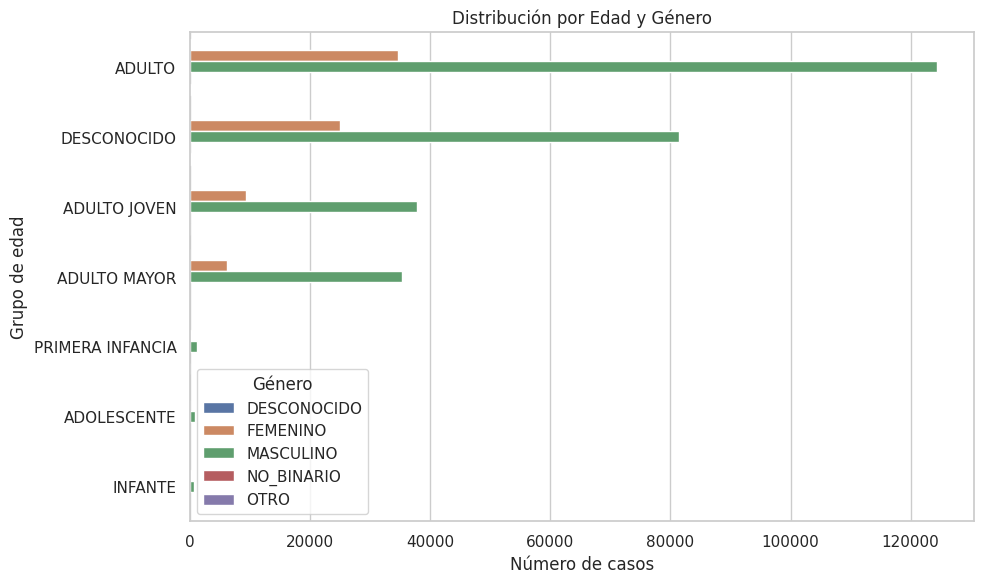

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='grupo_edad', hue='g_nero', order=df['grupo_edad'].value_counts().index)
plt.title('Distribución por Edad y Género')
plt.xlabel('Número de casos')
plt.ylabel('Grupo de edad')
plt.legend(title='Género')
plt.tight_layout()
plt.show()

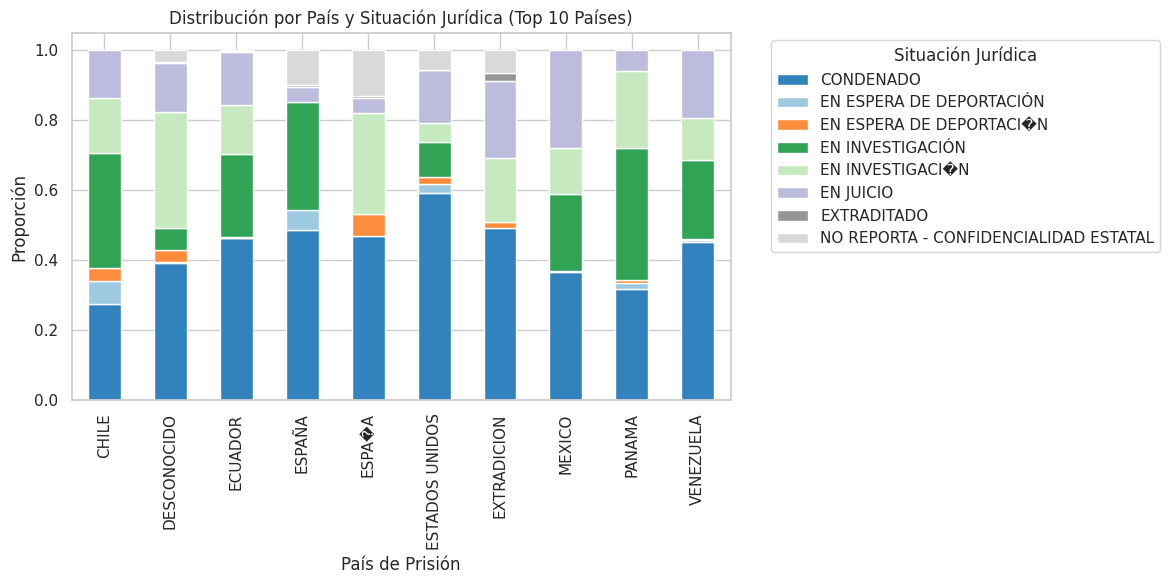

In [ ]:
top_paises = df['pais_prisi_n'].value_counts().head(10).index
df_top = df[df['pais_prisi_n'].isin(top_paises)]

# Tabla cruzada normalizada por fila
ct = pd.crosstab(df_top['pais_prisi_n'], df_top['situaci_n_jur_dica'], normalize='index')

# Gráfico
ct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20c')
plt.title('Distribución por País y Situación Jurídica (Top 10 Países)')
plt.xlabel('País de Prisión')
plt.ylabel('Proporción')
plt.legend(title='Situación Jurídica', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

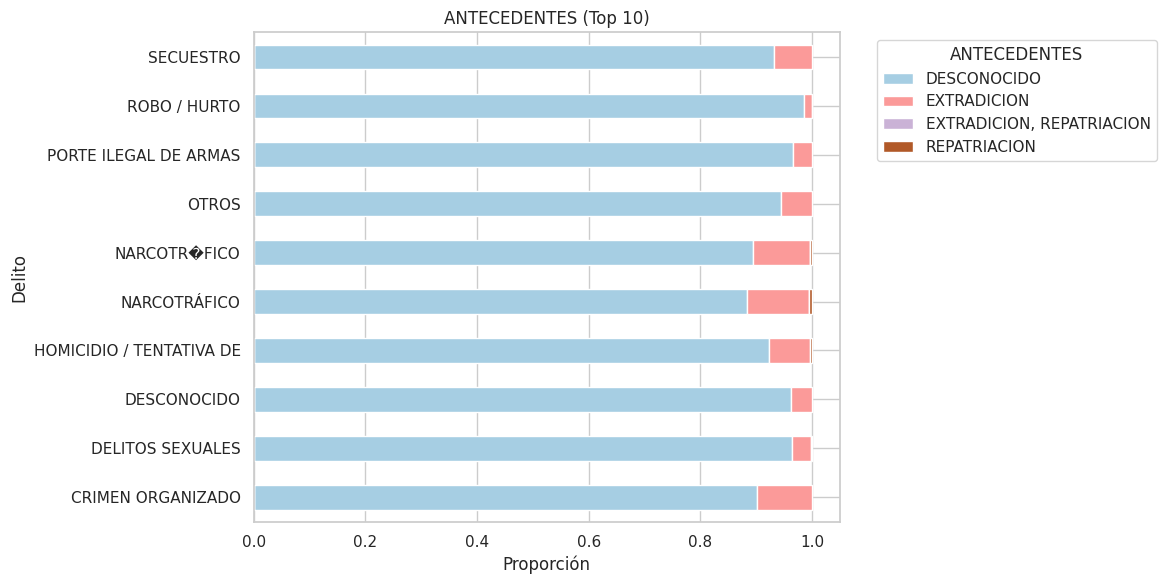

In [ ]:
# Seleccionar los delitos más comunes para visualización clara
top_delitos = df['delito'].value_counts().head(10).index
df_top_delitos = df[df['delito'].isin(top_delitos)]

# Crear tabla cruzada
cruce = pd.crosstab(df_top_delitos['delito'], df_top_delitos['extraditado_y_o_repatriado'], normalize='index')

# Gráfico de barras
cruce.plot(kind='barh', stacked=True, figsize=(12, 6), colormap='Paired')
plt.title('ANTECEDENTES (Top 10)')
plt.xlabel('Proporción')
plt.ylabel('Delito')
plt.legend(title='ANTECEDENTES', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

TIPO DELITO CON EDAD

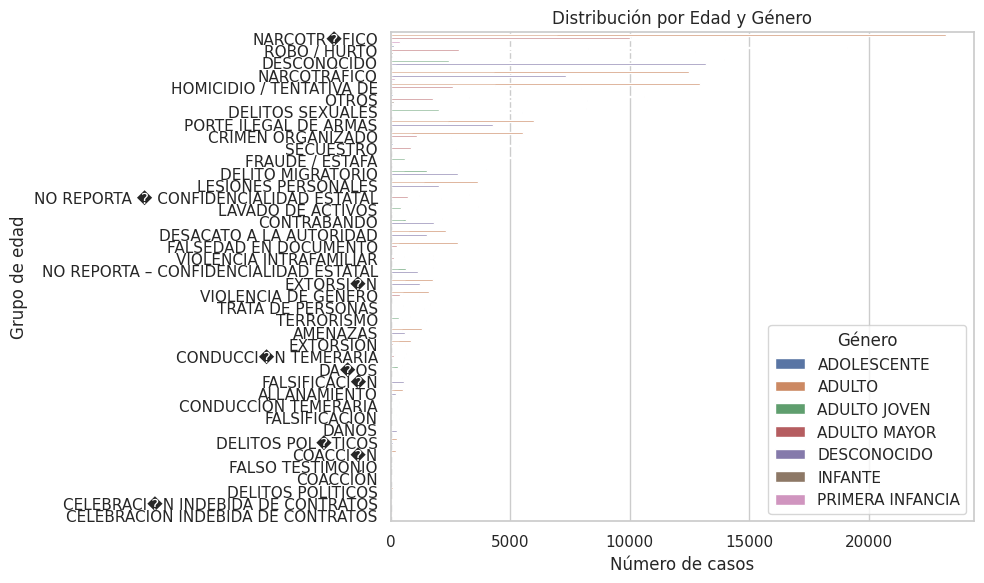

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='delito', hue='grupo_edad', order=df['delito'].value_counts().index)
plt.title('Distribución por Edad y Género')
plt.xlabel('Número de casos')
plt.ylabel('Grupo de edad')
plt.legend(title='Género')
plt.tight_layout()
plt.show()

Interpretación:

*   Visualizar los países y consulados con más detenciones.

*   Observar qué delitos, situaciones jurídicas y grupos de edad son más frecuentes.

In [ ]:
df.groupby('situaci_n_jur_dica').size()

<ipython-input-25-5d6b4bfc39b9>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('situaci_n_jur_dica').size()


,0
situaci_n_jur_dica,
CONDENADO,150958
EN ESPERA DE DEPORTACIÓN,4047
EN ESPERA DE DEPORTACI�N,8981
EN INVESTIGACIÓN,44378
EN INVESTIGACI�N,85920
EN JUICIO,51143
EXTRADITADO,1225
NO REPORTA - CONFIDENCIALIDAD ESTATAL,11348


In [ ]:
sns.set(style="whitegrid")

df_pre = df.copy()

# cambiar 'NARCOTR�FICO' a 'NARCOTRÁFICO' en la columna 'delito'
df_pre['delito'] = df_pre['delito'].replace('NARCOTR�FICO', 'NARCOTRÁFICO')
# cambiar 'ESPA�A' a 'ESPAÑA' en la columna 'pais_prisi_n'
df_pre['pais_prisi_n'] = df_pre['pais_prisi_n'].replace('ESPA�A', 'ESPAÑA')

# cambiar 'ESPA�A' a 'ESPAÑA' en la columna 'situaci_n_jur_dica'
df_pre['situaci_n_jur_dica'] = df_pre['situaci_n_jur_dica'].replace('EN ESPERA DE DEPORTACI�N', 'EN ESPERA DE DEPORTACIÓN')
df_pre['situaci_n_jur_dica'] = df_pre['situaci_n_jur_dica'].replace('EN INVESTIGACI�N', 'EN INVESTIGACIÓN')


<ipython-input-26-2852fa30f64c>:6: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_pre['delito'] = df_pre['delito'].replace('NARCOTR�FICO', 'NARCOTRÁFICO')
<ipython-input-26-2852fa30f64c>:8: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_pre['pais_prisi_n'] = df_pre['pais_prisi_n'].replace('ESPA�A', 'ESPAÑA')
<ipython-input-26-2852fa30f64c>:11: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, 

In [ ]:
categorical_cols1 = [
    'pais_prisi_n', 'delito'
]

for col in categorical_cols1:
    frec1 = df_pre[col].value_counts(normalize=True).head(10)
    print(f"\nTop 10 categorías en '{col}':")
    print(frec1)


Top 10 categorías en 'pais_prisi_n':
pais_prisi_n
DESCONOCIDO       0.563405
VENEZUELA         0.073925
ESTADOS UNIDOS    0.067958
ESPAÑA            0.060408
ECUADOR           0.050221
EXTRADICION       0.025383
CHILE             0.020799
MEXICO            0.013087
PANAMA            0.011598
ITALIA            0.010397
Name: proportion, dtype: float64

Top 10 categorías en 'delito':
delito
NARCOTRÁFICO                0.236089
ROBO / HURTO                0.121416
DESCONOCIDO                 0.100757
HOMICIDIO / TENTATIVA DE    0.077905
OTROS                       0.067349
DELITOS SEXUALES            0.053511
PORTE ILEGAL DE ARMAS       0.038020
CRIMEN ORGANIZADO           0.028070
SECUESTRO                   0.027542
FRAUDE / ESTAFA             0.026796
Name: proportion, dtype: float64


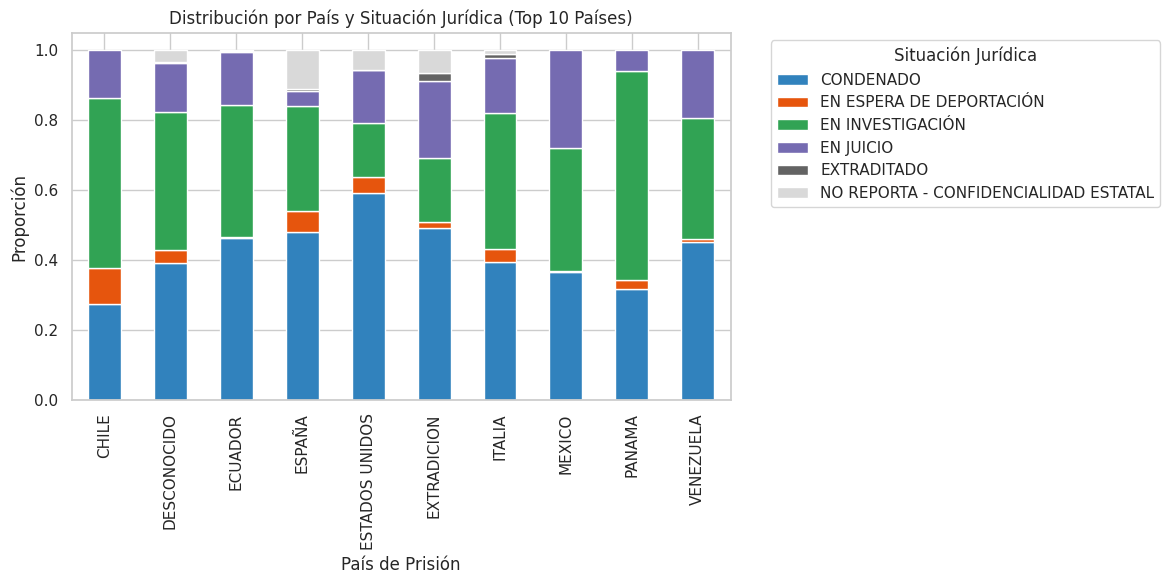

In [ ]:
top_paises = df_pre['pais_prisi_n'].value_counts().head(10).index
df_top_pre = df_pre[df_pre['pais_prisi_n'].isin(top_paises)]

# Tabla cruzada normalizada por fila
ct = pd.crosstab(df_top_pre['pais_prisi_n'], df_top_pre['situaci_n_jur_dica'], normalize='index')

# Gráfico
ct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20c')
plt.title('Distribución por País y Situación Jurídica (Top 10 Países)')
plt.xlabel('País de Prisión')
plt.ylabel('Proporción')
plt.legend(title='Situación Jurídica', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

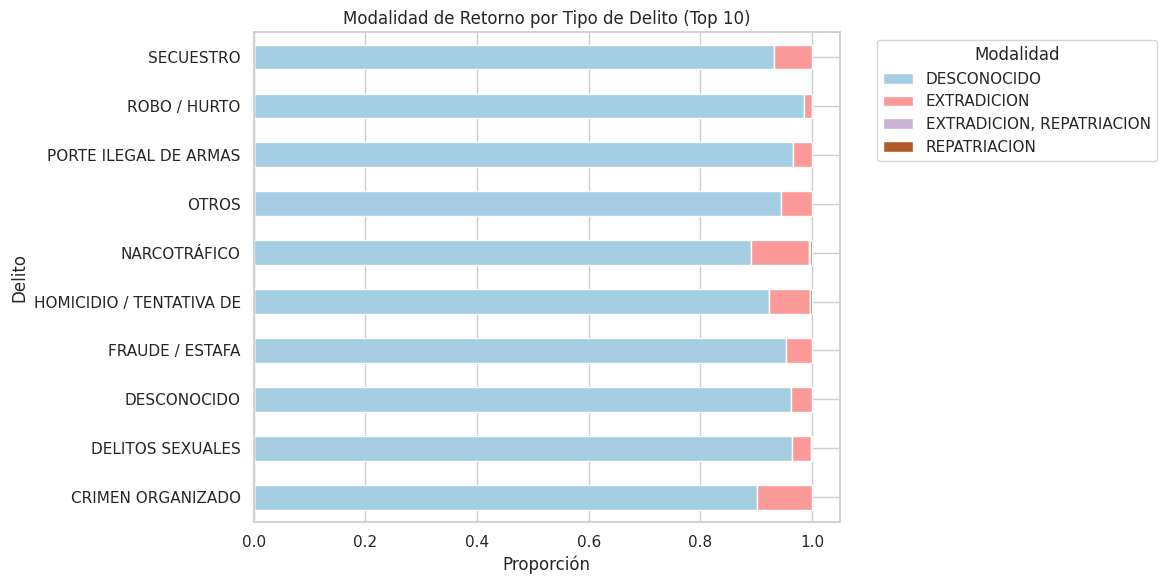

In [ ]:
# Seleccionar los delitos más comunes para visualización clara
top_delitos1 = df_pre['delito'].value_counts().head(10).index
df_top_delitos1 = df_pre[df_pre['delito'].isin(top_delitos1)]

# Crear tabla cruzada
cruce = pd.crosstab(df_top_delitos1['delito'], df_top_delitos1['extraditado_y_o_repatriado'], normalize='index')

# Gráfico de barras
cruce.plot(kind='barh', stacked=True, figsize=(12, 6), colormap='Paired')
plt.title('Modalidad de Retorno por Tipo de Delito (Top 10)')
plt.xlabel('Proporción')
plt.ylabel('Delito')
plt.legend(title='Modalidad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
def unique_counts(df: pd.DataFrame, column: str) -> pd.Series:

    counts = df[column].value_counts(dropna=False)
    print(f"Recuento de valores para la columna '{column}':\n")
    print(counts)
    return counts

delito_counts = unique_counts(df, 'pais_prisi_n')

Recuento de valores para la columna 'pais_prisi_n':

pais_prisi_n
DESCONOCIDO       201699
VENEZUELA          26465
ESTADOS UNIDOS     24329
ECUADOR            17979
ESPAÑA             13696
                   ...  
ESLOVENIA             12
NIGERIA               12
GUINEA                 7
LIBANO                 4
NORUEGA                2
Name: count, Length: 93, dtype: int64


In [ ]:
sns.set(style="whitegrid")

# --- Función para resumir datos faltantes ---
def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    miss = df.isnull().sum()
    miss_pct = 100 * miss / len(df)
    summary = pd.DataFrame({
        'missing_count': miss,
        'missing_pct': miss_pct.round(2)
    }).sort_values('missing_count', ascending=False)
    print("Resumen de datos faltantes por columna:\n")
    display(summary)
    return summary


missing_df = missing_summary(df)


Resumen de datos faltantes por columna:



,missing_count,missing_pct
geocoded_column,236173,65.97
latitud,44322,12.38
longitud,44322,12.38
pais_prisi_n,0,0.00
fecha_publicaci_n,0,0.00
extraditado_y_o_repatriado,0,0.00
delito,0,0.00
consulado,0,0.00
situaci_n_jur_dica,0,0.00
grupo_edad,0,0.00


<ipython-input-32-f83480a03db5>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


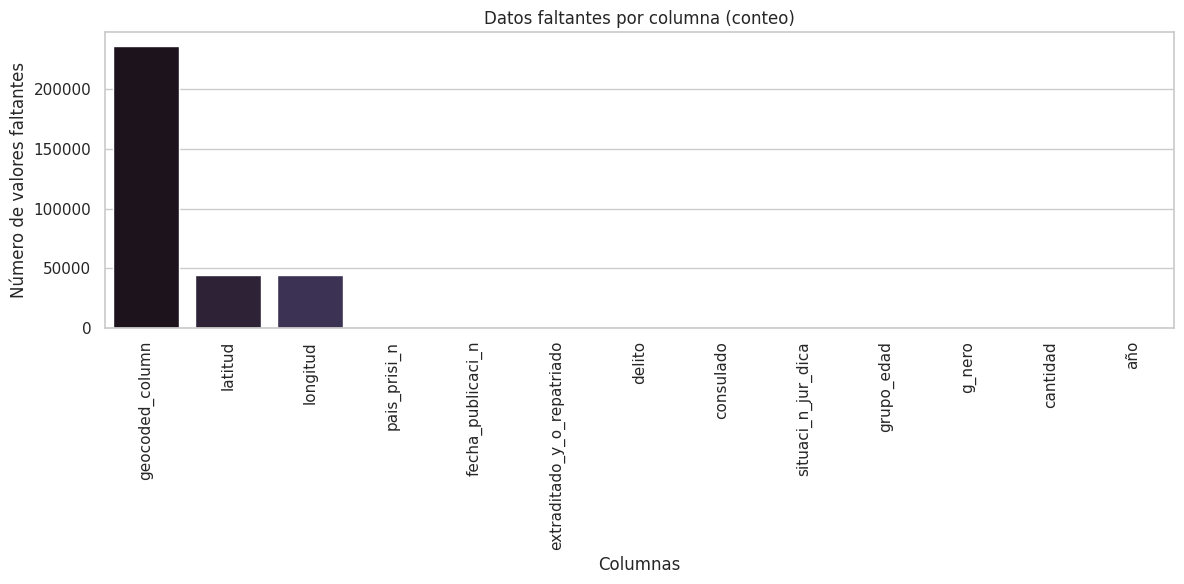

<ipython-input-32-f83480a03db5>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


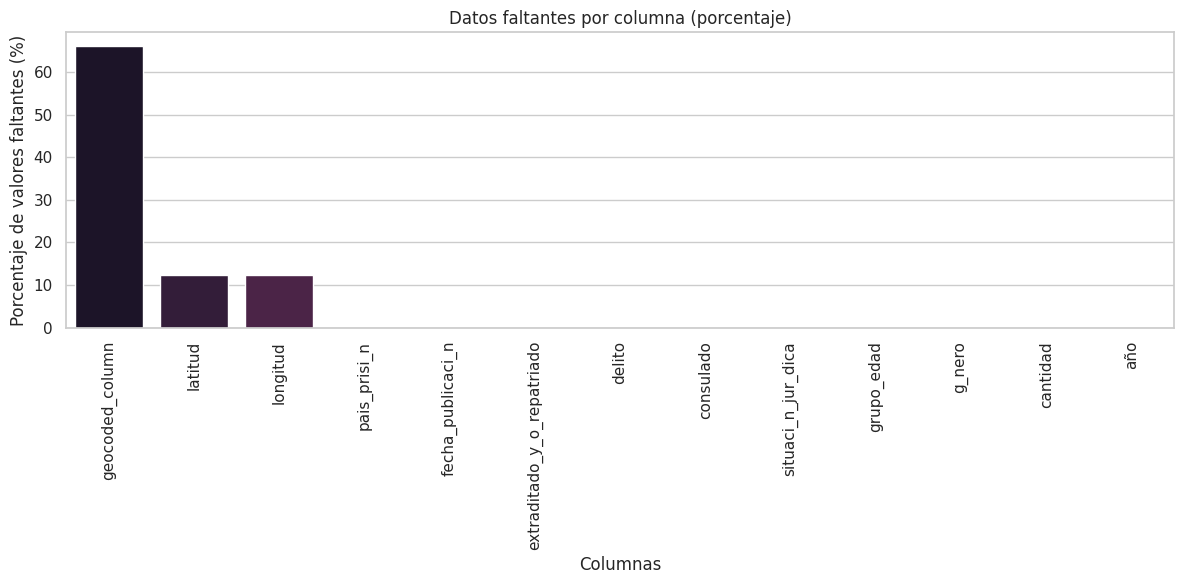

In [ ]:
# Gráfico de barras de conteo de nulos
plt.figure(figsize=(12, 6))
sns.barplot(
    x=missing_df.index,
    y='missing_count',
    data=missing_df.reset_index().rename(columns={'index':'column'}),
    palette='mako'
)
plt.xticks(rotation=90)
plt.ylabel("Número de valores faltantes")
plt.xlabel("Columnas")
plt.title("Datos faltantes por columna (conteo)")
plt.tight_layout()
plt.show()

# Gráfico de barras de porcentaje de nulos
plt.figure(figsize=(12, 6))
sns.barplot(
    x=missing_df.index,
    y='missing_pct',
    data=missing_df.reset_index().rename(columns={'index':'column'}),
    palette='rocket'
)
plt.xticks(rotation=90)
plt.ylabel("Porcentaje de valores faltantes (%)")
plt.xlabel("Columnas")
plt.title("Datos faltantes por columna (porcentaje)")
plt.tight_layout()
plt.show()


In [ ]:
print(results_df.tail())

       fecha_publicaci_n pais_prisi_n          consulado  \
357995        2025-05-01  DESCONOCIDO      C. ESMERALDAS   
357996        2025-05-01  DESCONOCIDO  C. PUERTO LA CRUZ   
357997        2025-05-01  DESCONOCIDO          C. MEXICO   
357998        2025-05-01  DESCONOCIDO    BTA. ASISTENCIA   
357999        2025-05-01  DESCONOCIDO           C. BERNA   

                       delito extraditado_y_o_repatriado situaci_n_jur_dica  \
357995           NARCOTR�FICO                DESCONOCIDO   EN INVESTIGACI�N   
357996                  OTROS                DESCONOCIDO          CONDENADO   
357997  PORTE ILEGAL DE ARMAS                DESCONOCIDO   EN INVESTIGACI�N   
357998      TRATA DE PERSONAS                DESCONOCIDO   EN INVESTIGACI�N   
357999       DELITOS SEXUALES                DESCONOCIDO          CONDENADO   

           g_nero   grupo_edad geocoded_column cantidad    latitud  \
357995  MASCULINO  DESCONOCIDO             NaN        9  -1.831239   
357996  MASCULINO       